### Lista 4

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import seaborn as sns

In [16]:

class MLP:
    def __init__(self, layer_sizes, problem_type="regression", seed=42069):
        self.layer_sizes = layer_sizes
        self.problem_type = problem_type
        self.num_layers = len(layer_sizes)
        np.random.seed(seed)
        self.W = [np.random.randn(layer_sizes[i], layer_sizes[i-1]) * np.sqrt(2. / layer_sizes[i-1]) for i in range(1, self.num_layers)]
        self.b = [np.zeros((layer_sizes[i], 1)) for i in range(1, self.num_layers)]
        self.v_W = [np.zeros_like(w) for w in self.W]
        self.v_b = [np.zeros_like(b) for b in self.b]

    def relu(self, Z):
        return np.maximum(0, Z)
    
    def relu_derivative(self, Z):
        return (Z > 0).astype(float)
    
    def softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return expZ / np.sum(expZ, axis=0, keepdims=True)
    
    def forward(self, X):
        self.A = [X]
        self.Z = []
        A = X
        for i in range(self.num_layers - 2):
            Z = np.dot(self.W[i], A) + self.b[i]
            A = self.relu(Z)
            self.Z.append(Z)
            self.A.append(A)
        Z = np.dot(self.W[-1], A) + self.b[-1]
        self.Z.append(Z)
        if self.problem_type == "regression":
            A = Z
        else:
            A = self.softmax(Z)
        self.A.append(A)
        return A
    
    def compute_loss(self, Y_pred, Y):
        m = Y.shape[1]
        if self.problem_type == "regression":
            return (1/(2*m)) * np.sum((Y_pred - Y)**2)
        else:
            return -(1/m) * np.sum(Y * np.log(Y_pred + 1e-8))
        
    def backward(self, Y):
        m = Y.shape[1]
        self.dW = [np.zeros_like(w) for w in self.W]
        self.db = [np.zeros_like(b) for b in self.b]
        dZ = self.A[-1] - Y
        self.dW[-1] = (1/m) * np.dot(dZ, self.A[-2].T)
        self.db[-1] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        for i in reversed(range(self.num_layers - 2)):
            dA = np.dot(self.W[i+1].T, dZ)
            dZ = dA * self.relu_derivative(self.Z[i])
            self.dW[i] = (1/m) * np.dot(dZ, self.A[i].T)
            self.db[i] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

    def update_params(self, lr, momentum):
        for i in range(len(self.W)):
            self.v_W[i] = momentum * self.v_W[i] - lr * self.dW[i]
            self.v_b[i] = momentum * self.v_b[i] - lr * self.db[i]
            self.W[i] += self.v_W[i]
            self.b[i] += self.v_b[i]

    def get_batches(self, X, Y, batch_size):
        m = X.shape[1]
        permutation = list(np.random.permutation(m))
        shuffled_X = X[:, permutation]
        shuffled_Y = Y[:, permutation]
        batches = []
        num_complete = m // batch_size
        for k in range(num_complete):
            batch_X = shuffled_X[:, k*batch_size:(k+1)*batch_size]
            batch_Y = shuffled_Y[:, k*batch_size:(k+1)*batch_size]
            batches.append((batch_X, batch_Y))
        if m % batch_size != 0:
            batch_X = shuffled_X[:, num_complete*batch_size:]
            batch_Y = shuffled_Y[:, num_complete*batch_size:]
            batches.append((batch_X, batch_Y))
        return batches
    
    def train(self, X_train, Y_train, X_val, Y_val, epochs, batch_size, lr, momentum):
        train_costs, val_costs = [], []
        for epoch in range(epochs):
            batches = self.get_batches(X_train, Y_train, batch_size)
            for batch_X, batch_Y in batches:
                self.forward(batch_X)
                self.backward(batch_Y)
                self.update_params(lr, momentum)
            train_costs.append(self.compute_loss(self.forward(X_train), Y_train))
            val_costs.append(self.compute_loss(self.forward(X_val), Y_val))
        return train_costs, val_costs

Questão 1

In [17]:
data_q1 = pd.read_csv("concrete.csv", header=None)
X_q1 = data_q1.iloc[:, :-1].values
y_q1 = data_q1.iloc[:, -1].values.reshape(-1, 1)
X_train_val, X_test, y_train_val, y_test = train_test_split(X_q1, y_q1, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train).T
X_val = scaler_X.transform(X_val).T
X_test = scaler_X.transform(X_test).T
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train).T
y_val = scaler_y.transform(y_val).T
y_test = scaler_y.transform(y_test).T

hidden_layer_sizes = [4, 8, 16, 32, 64, 128]
learning_rates = [0.01, 0.05, 0.1]
momentums = [0.8, 0.9, 0.95]
best_val_loss = float("inf")
best_hparams = None
best_model = None
best_curves = None
for hidden_size in hidden_layer_sizes:
    for lr in learning_rates:
        for momentum in momentums:
            model = MLP(layer_sizes=[8, hidden_size, 1], problem_type="regression")
            train_costs, val_costs = model.train(X_train, y_train, X_val, y_val, epochs=200, batch_size=32, lr=lr, momentum=momentum)
            if val_costs[-1] < best_val_loss:
                best_val_loss = val_costs[-1]
                best_hparams = (hidden_size, lr, momentum)
                best_model = model
                best_curves = (train_costs, val_costs)
print(f"Hiperparametros: Neurônios Ocultos={best_hparams[0]}, LR={best_hparams[1]}, Momentum={best_hparams[2]}")

Hiperparametros: Neurônios Ocultos=64, LR=0.05, Momentum=0.95


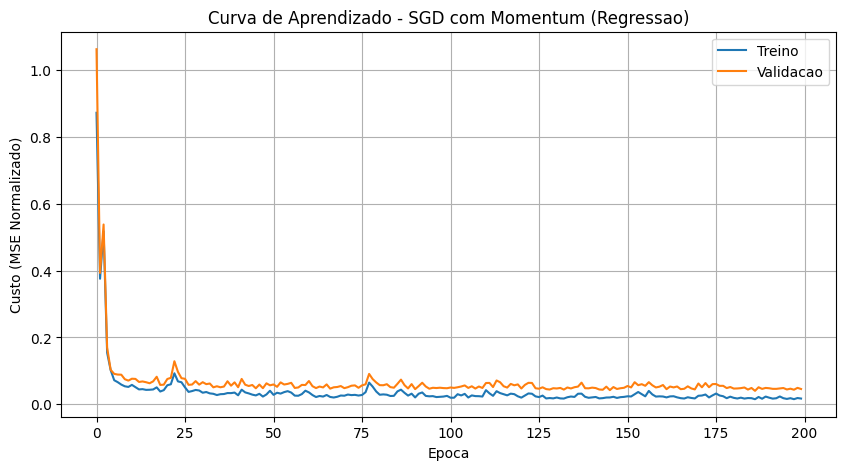

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(best_curves[0], label="Treino")
plt.plot(best_curves[1], label="Validacao")
plt.title("Curva de Aprendizado - SGD com Momentum (Regressao)")
plt.xlabel("Epoca")
plt.ylabel("Custo (MSE Normalizado)")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def evaluate_regression(X, y_true_norm, dataset_name):
    y_pred_norm = best_model.forward(X)
    y_pred = scaler_y.inverse_transform(y_pred_norm.T)
    y_true = scaler_y.inverse_transform(y_true_norm.T)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mre = np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + 1e-8))
    print(f"Metricas conjunto {dataset_name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MRE:  {mre:.4f}\n")
evaluate_regression(X_train, y_train, "Treinamento")
evaluate_regression(X_val, y_val, "Validacao")
evaluate_regression(X_test, y_test, "Teste")

Metricas conjunto Treinamento:
  RMSE: 3.1025
  MAE:  2.3142
  MRE:  0.0935

Metricas conjunto Validacao:
  RMSE: 5.0450
  MAE:  3.6183
  MRE:  0.1363

Metricas conjunto Teste:
  RMSE: 5.1451
  MAE:  3.6998
  MRE:  0.1380



Questão 2 - Classificação (vehicle.csv)

In [20]:
data_q2 = pd.read_csv("vehicle.csv", header=None)
X_q2 = data_q2.iloc[:, :-1].values
y_q2 = data_q2.iloc[:, -1].values.astype(int)
num_classes = len(np.unique(y_q2))
y_q2_oh = np.zeros((y_q2.size, num_classes))
y_q2_oh[np.arange(y_q2.size), y_q2] = 1
X_train_val, X_test, y_train_val_oh, y_test_oh, y_train_val, y_test = train_test_split(X_q2, y_q2_oh, y_q2, test_size=0.2, random_state=42, stratify=y_q2)
X_train, X_val, y_train_oh, y_val_oh, y_train, y_val = train_test_split(X_train_val, y_train_val_oh, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

scaler_X_classify = StandardScaler()
X_train = scaler_X_classify.fit_transform(X_train).T
X_val = scaler_X_classify.transform(X_val).T
X_test = scaler_X_classify.transform(X_test).T
y_train_oh = y_train_oh.T
y_val_oh = y_val_oh.T

hidden_layer_sizes = [4, 8, 16, 32, 64, 128]
learning_rates = [0.01, 0.05, 0.1]
momentums = [0.8, 0.9, 0.95]
best_val_loss = float("inf")
best_hparams_classify = None
best_model_classify = None
best_curves_classify = None
for hidden_size in hidden_layer_sizes:
    for lr in learning_rates:
        for momentum in momentums:
            model = MLP(layer_sizes=[18, hidden_size, num_classes], problem_type="classification")
            train_costs, val_costs = model.train(X_train, y_train_oh, X_val, y_val_oh, epochs=200, batch_size=32, lr=lr, momentum=momentum)
            if val_costs[-1] < best_val_loss:
                best_val_loss = val_costs[-1]
                best_hparams_classify = (hidden_size, lr, momentum)
                best_model_classify = model
                best_curves_classify = (train_costs, val_costs)
print(f"Hiperparametros: Neurônios Ocultos={best_hparams_classify[0]}, LR={best_hparams_classify[1]}, Momentum={best_hparams_classify[2]}")

Hiperparametros: Neurônios Ocultos=128, LR=0.01, Momentum=0.8


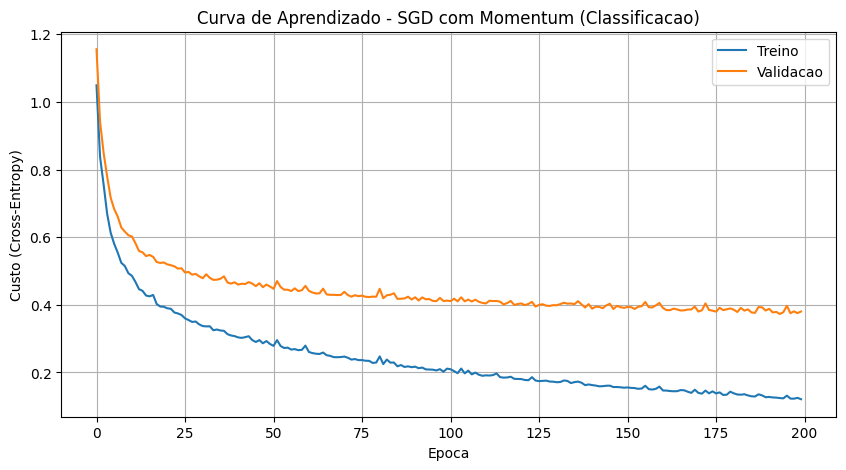

Metricas conjunto Treinamento:
  Acuracia:  0.9704
  Recall: 0.9710
  Precisao:  0.9715
  F1-Score:  0.9709

Metricas conjunto Validacao:
  Acuracia:  0.8225
  Recall: 0.8233
  Precisao:  0.8212
  F1-Score:  0.8216

Metricas conjunto Teste:
  Acuracia:  0.8000
  Recall: 0.8008
  Precisao:  0.8016
  F1-Score:  0.8005



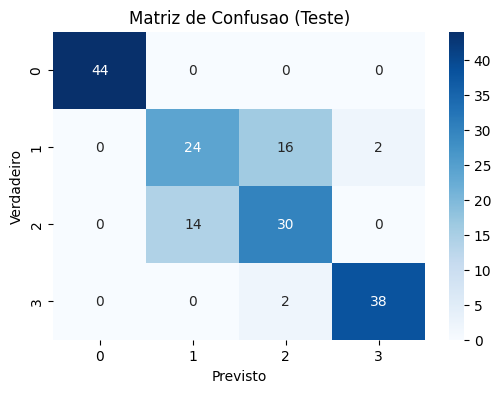

In [21]:
import warnings
warnings.filterwarnings("ignore")
plt.figure(figsize=(10, 5))
plt.plot(best_curves_classify[0], label="Treino")
plt.plot(best_curves_classify[1], label="Validacao")
plt.title("Curva de Aprendizado - SGD com Momentum (Classificacao)")
plt.xlabel("Epoca")
plt.ylabel("Custo (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.show()
def evaluate_classification(X, y_true, dataset_name):
    y_pred_oh = best_model_classify.forward(X)
    y_pred = np.argmax(y_pred_oh, axis=0)
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, average="macro")
    prec = precision_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"Metricas conjunto {dataset_name}:")
    print(f"  Acuracia:  {acc:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  Precisao:  {prec:.4f}")
    print(f"  F1-Score:  {f1:.4f}\n")
    return y_pred
evaluate_classification(X_train, y_train, "Treinamento")
evaluate_classification(X_val, y_val, "Validacao")
y_pred_test = evaluate_classification(X_test, y_test, "Teste")
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusao (Teste)")
plt.xlabel("Previsto")
plt.ylabel("Verdadeiro")
plt.show()